In [55]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
df = pd.read_parquet("../data/final_df.parquet")
df = df[df["phage_id"] != "NC_000913.3"]
df

,protein_id,namespace,ribosome,embedding,phage_id,description
100,XPK40951.1,molecular_function,False,"[125.5588, -79.63523, 75.97162, 12.756238, 71....",PQ850602,internal virion protein with endolysin domain
101,XPK43261.1,molecular_function,False,"[99.659424, -51.160362, 66.22639, -51.286892, ...",PQ850628,transglycosylase
102,XPK41564.1,molecular_function,False,"[111.65291, -51.645664, 76.171875, -51.0761, 9...",PQ850610,transglycosylase
104,XPK40440.1,molecular_function,False,"[132.59705, -90.81759, 72.479294, 24.789663, 7...",PQ850595,internal virion protein with endolysin domain
105,QXV76843.1,molecular_function,False,"[127.90173, -77.47774, 69.211945, 22.287302, 7...",MZ501055,DNA injection protein C
...,...,...,...,...,...,...
11172,YP_006843.1,molecular_function,False,"[56.490303, -98.886856, 116.335396, 55.581356,...",NC_005859.1,hypothetical protein
11173,QXV85222.1,molecular_function,False,"[39.115974, -111.263466, 83.92349, 12.382543, ...",MZ501108,hypothetical protein
11174,QXV80335.1,molecular_function,False,"[41.742188, -129.28825, 105.71013, 18.93979, 1...",MZ501075,hypothetical protein
11175,QXV77353.1,molecular_function,False,"[45.662178, -141.82974, 106.98464, 54.453396, ...",MZ501058,hypothetical protein


# TSNE

In [68]:
X = np.vstack(df["embedding"].values)

tsne = TSNE(n_components=2, random_state=42, perplexity=100, max_iter=1000)
X_tsne = tsne.fit_transform(X)

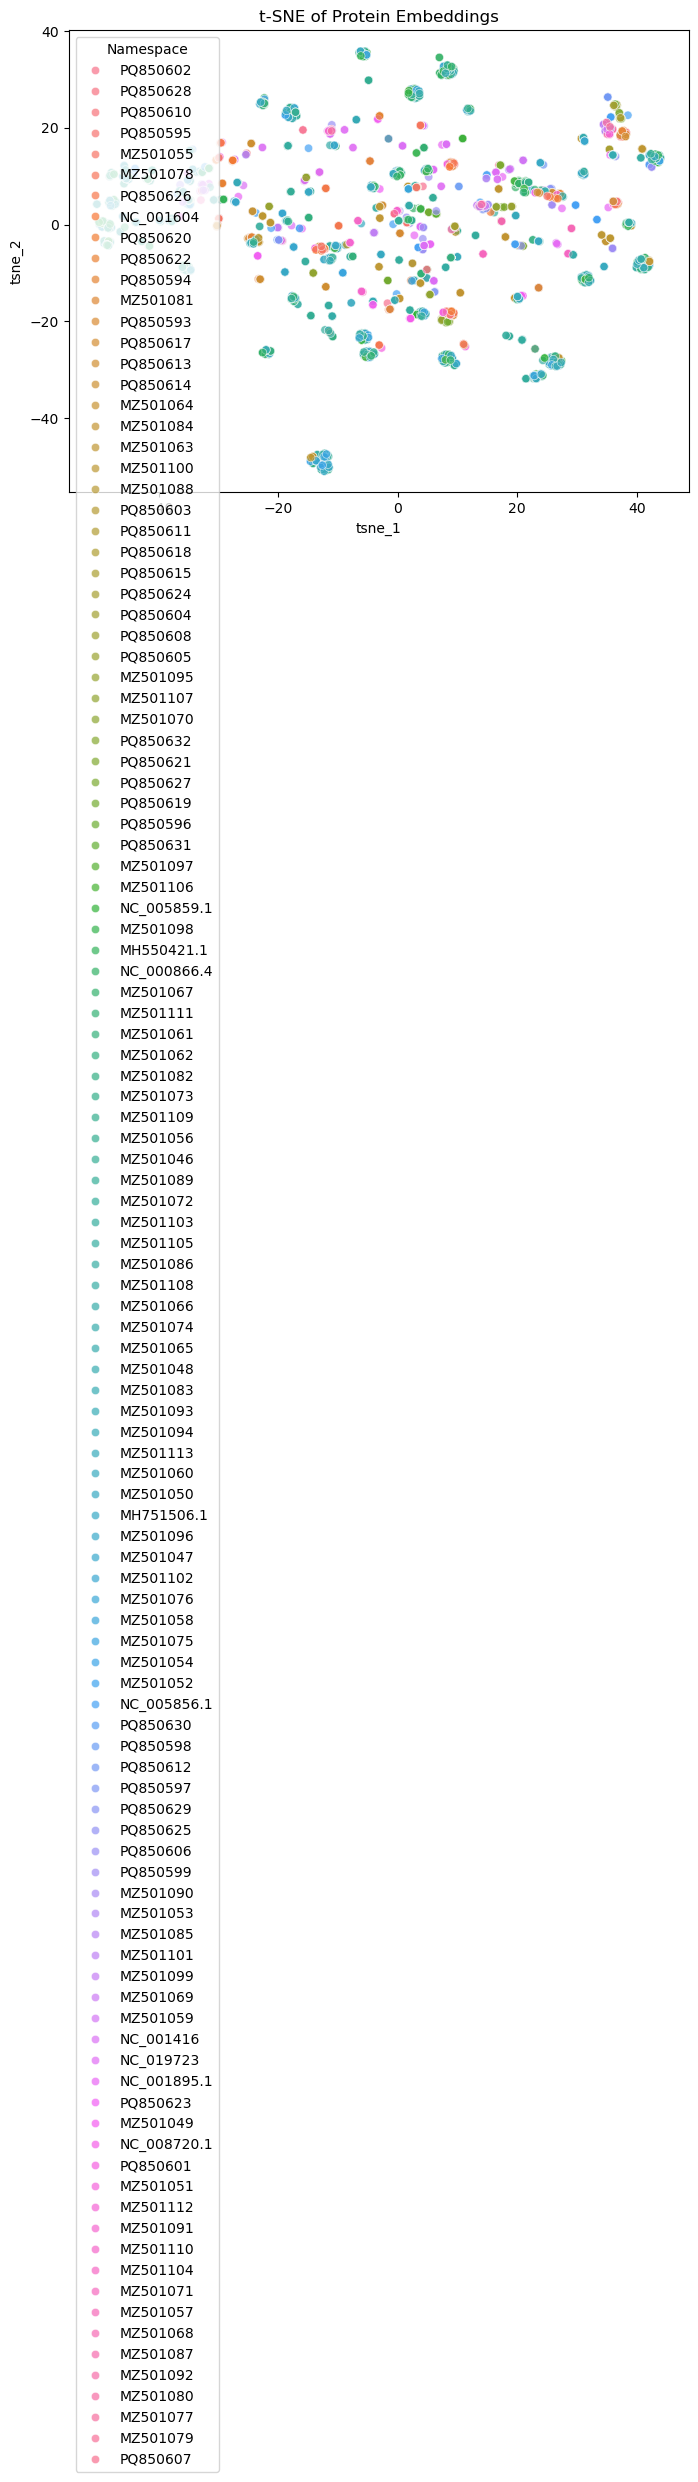

In [ ]:
df["tsne_1"] = X_tsne[:, 0]
df["tsne_2"] = X_tsne[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="tsne_1", y="tsne_2", hue="namespace", alpha=0.7)
plt.title("t-SNE of Protein Embeddings")
plt.legend(title="Namespace")
plt.show()